# k-means applied to wintertime North American temperature

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/kmeans_applicationWeather.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-27*

## Learning objectives

- Apply k-means clustering to a real geophysical dataset (daily surface temperature anomalies over North America).
- Read each cluster centroid as a **map** — a recurring spatial pattern of anomalies.
- Summarize how often each cluster occurs across the sample.

## About the data

Wintertime (DJF) daily anomalous surface temperatures over North America from an atmosphere-only, time-slice experiment with NCAR's CESM2. The run is part of the Polar Amplification MIP (PAMIP) with present-day SSTs and pre-industrial sea ice. The full ensemble has 100 one-year members; we use a 20-year subset. A 7-day low-pass filter has been applied and the data are area-weighted. Anomalies are taken relative to the daily ensemble mean, so the data carry only synoptic-to-subseasonal variability — no interannual signal.

The point isn't to discover a new climate mode; it's to *practice* clustering and centroid interpretation.

## Setup

In [1]:
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = False


In [2]:
import warnings

warnings.filterwarnings("ignore")

if IN_COLAB:
    try:
        import cartopy  # noqa: F401
    except ImportError:
        get_ipython().system("pip install cartopy")
    try:
        import cmocean  # noqa: F401
    except ImportError:
        get_ipython().system("pip install cmocean")

import cartopy.crs as ccrs
import cmocean
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from cartopy.util import add_cyclic_point
from scipy.cluster.vq import kmeans, vq

mpl.rcParams["figure.dpi"] = 100
map_proj = ccrs.PlateCarree(central_longitude=0.0)

SEED = 99
np.random.seed(SEED)  # scipy.cluster.vq.kmeans uses the legacy global state


## A cartopy plotting helper

Draw a 2-D lat/lon field with coastlines and a cyclic seam at 360 degrees.

In [3]:
def draw_on_globe(
    ax,
    data,
    lats,
    lons,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    cbar=True,
    extent="both",
):
    data_cyc, lons_cyc = add_cyclic_point(data, coord=lons)
    ax.set_global()
    ax.coastlines(linewidth=1.2, color="black")
    image = ax.pcolormesh(
        lons_cyc,
        lats,
        data_cyc,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    if cbar:
        cb = plt.colorbar(
            image, shrink=0.75, orientation="vertical", pad=0.02, extend=extent
        )
        cb.ax.tick_params(labelsize=6)
    else:
        cb = None
    return cb, image

## Load the data

In [4]:
if IN_COLAB:
    get_ipython().system(
        "wget -q https://raw.githubusercontent.com/eabarnes1010/course_objective_analysis/main/data/tas_DJFdays_PAMIP_CESM2_NorthAmerica.nc"
    )
    filename = "tas_DJFdays_PAMIP_CESM2_NorthAmerica.nc"
else:
    filename = "../data/tas_DJFdays_PAMIP_CESM2_NorthAmerica.nc"

da = xr.open_dataset(filename)
data = da["__xarray_dataarray_variable__"].values   # (time, lat, lon)
lat = da["latitude"]
lon = da["longitude"]

da.head()


<xarray.Dataset> Size: 1kB
Dimensions:                        (time: 5, latitude: 5, longitude: 5)
Coordinates:
  * time                           (time) int64 40B 1 2 3 4 5
  * latitude                       (latitude) float64 40B 1.0 3.0 5.0 7.0 9.0
  * longitude                      (longitude) float64 40B 200.0 202.0 ... 208.0
Data variables:
    __xarray_dataarray_variable__  (time, latitude, longitude) float64 1kB 0....

## Run k-means

`scipy.cluster.vq.kmeans` returns the cluster centroids and the *quantization error* (sum of squared distances from each sample to its assigned centroid). `vq` then labels each daily map with its nearest cluster.

The `iter` argument is the number of random restarts — k-means converges to a local optimum, so multiple restarts and picking the best result is the standard trick. Bigger numbers are slower.

In [5]:
# --- Modify these ---
n_clusters = 6
n_restarts = 20
# --------------------

# Flatten (lat, lon) -> a single feature vector per day for k-means.
flat = data.reshape(data.shape[0], data.shape[1] * data.shape[2])

clusters, dist = kmeans(flat, n_clusters, iter=n_restarts)
classes, _ = vq(flat, clusters)

print(f"clusters shape = {clusters.shape}")
print(f"classes shape = {classes.shape}")
print(f"quantization error (lower is tighter clusters) = {dist:.3f}")

clusters shape = (6, 2745)
classes shape = (1800,)
quantization error (lower is tighter clusters) = 80.085


## Plot the cluster centroids

Each centroid is a map of temperature anomalies (Kelvin). Look for recurring weather patterns — warm/cold lobes over different parts of the continent.

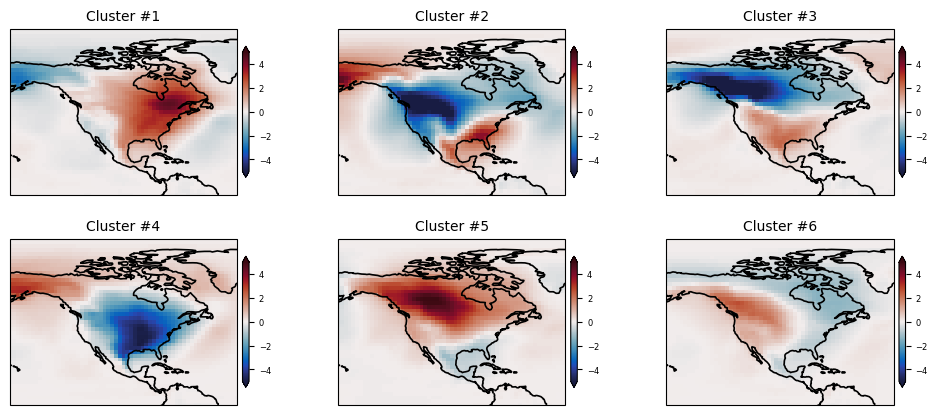

In [6]:
max_val = 5.0
title_size = 10
cmap = cmocean.cm.balance
extent = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]

plt.figure(figsize=(12, 5))
for cluster in range(n_clusters):
    ax = plt.subplot(
        2, int(np.ceil(n_clusters / 2.0)), cluster + 1, projection=map_proj
    )
    centroid_map = clusters[cluster, :].reshape(len(lat), len(lon))
    draw_on_globe(
        ax,
        centroid_map,
        np.squeeze(lat),
        np.squeeze(lon),
        cmap=cmap,
        vmin=-max_val,
        vmax=max_val,
    )
    ax.set_extent(extent)
    plt.title(f"Cluster #{cluster + 1}", fontsize=title_size)
plt.show()

## How often does each cluster occur?

A frequency count of `classes` tells us how popular each pattern is in the sample.

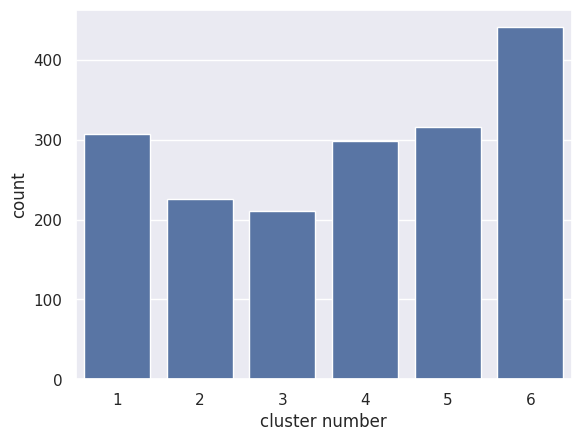

In [7]:
df_classes = pd.DataFrame({"class": classes + 1})

sns.set_theme(style="darkgrid")
sns.countplot(data=df_classes, x="class")
plt.xlabel("cluster number")
plt.show()

## Wrap-up

A few things to take away:

- The centroids are interpretable as **recurring weather patterns** — k-means turned a big stack of daily maps into a small library of representative ones.
- The choice of `n_clusters` is up to you and depends on what you want to see. Try a few values (4, 6, 9) and see how the patterns split or merge.
- The choice of `n_restarts` controls how confident you can be that you found a near-global optimum, not just one of many local ones.